In [1]:
import sys
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('../.'))

In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xso

from np_setups import (
    phyto_esd, zoo_esd, n_classes, n_zoo,
    model_open,
    model_npz_typeII, model_npz_typeIII,
    model_setup_open_const,
    model_setup_npz_typeII_matched,
    model_setup_npz_typeII_herb,
    model_setup_npz_typeII_omni,
    model_setup_npz_typeIII_matched,
    model_setup_npz_typeIII_herb,
    model_setup_npz_typeIII_omni,
)

F_N_ANCHOR        = 15.0      # mmol N m-2 d-1
SS_FLOOR          = 1e-12     # positive floor for fsolve seed
TAIL_FRAC         = 0.5       # use last 50% of the run as the tail
OSC_CV_THRESHOLD  = 0.01      # max CV above this → classify as limit cycle

RUNS_SPEC = [
    ('NP — open chemostat',     model_open,        model_setup_open_const),
    ('NPZ TypeII — matched',    model_npz_typeII,  model_setup_npz_typeII_matched),
    ('NPZ TypeII — herbivory',  model_npz_typeII,  model_setup_npz_typeII_herb),
    ('NPZ TypeII — omnivory',   model_npz_typeII,  model_setup_npz_typeII_omni),
    ('NPZ TypeIII — matched',   model_npz_typeIII, model_setup_npz_typeIII_matched),
    ('NPZ TypeIII — herbivory', model_npz_typeIII, model_setup_npz_typeIII_herb),
    ('NPZ TypeIII — omnivory',  model_npz_typeIII, model_setup_npz_typeIII_omni),
]


def tail_mean_and_cv(ivp_out, state_vars, tail_frac=TAIL_FRAC,
                     active_threshold=1e-4):
    """Tail-mean + max CV over classes whose tail-mean is above
    ``active_threshold`` (i.e. physically active, not floor-decayed)."""
    n_time   = ivp_out.sizes['time']
    tail_idx = int(n_time * (1.0 - tail_frac))
    tail     = ivp_out.isel(time=slice(tail_idx, None))

    tail_mean = {}
    max_cv = 0.0
    for v in state_vars:
        m = tail[v].mean('time')
        s = tail[v].std('time')
        tail_mean[v] = m
        # CV only on active entries; floor classes are excluded.
        active_mask = np.abs(m.values) > active_threshold
        if active_mask.any():
            cv = s.values[active_mask] / np.abs(m.values[active_mask])
            max_cv = max(max_cv, float(np.nanmax(cv)))
    return tail_mean, max_cv


# runs[label] = {
#   'ivp_out'        : xr.Dataset,
#   'ss_out'         : xr.Dataset or None,
#   'tail_mean'      : dict of xr.DataArray,
#   'is_oscillating' : bool,
#   'max_cv'         : float,
#   'seed_t_d'       : float — simulated time of the seed snapshot,
# }
runs = {}

print(f"F_N = {F_N_ANCHOR} mmol N m-2 d-1\n")
print(f"{'variant':<28s}   {'IVP':>8s}   {'fsolve':>8s}   "
      f"{'max CV':>7s}   {'dyn-type':<13s}")
print("-" * 78)

for label, mod, ivp_setup in RUNS_SPEC:
    is_npz = 'NPZ' in label
    state_vars = ['Nutrient__value', 'Phytoplankton__biomass']
    if is_npz:
        state_vars.append('Zooplankton__biomass')

    # --- 1. IVP transient (unchanged) ---
    t0 = time.time()
    with mod:
        ivp_out = (ivp_setup
                   .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': F_N_ANCHOR}})
                   .xsimlab.run())
    t_ivp = time.time() - t0

    # --- 2. Tail-mean + dynamic-type classification ---
    tail_mean, max_cv = tail_mean_and_cv(ivp_out, state_vars)
    is_oscillating = max_cv > OSC_CV_THRESHOLD
    dyn_type = 'limit cycle' if is_oscillating else 'fixed point'

    # --- 3. Seed fsolve from tail-mean (positive-clipped) ---
    # Better than the snapshot seed in both cases: for fixed-point runs
    # the tail-mean ≈ the fixed point; for limit-cycle runs the tail-mean
    # sits near the cycle's spiral focus, which is the most natural
    # fixed-point representative. fsolve still drifts to nearby
    # equilibria on oscillating cases, but the tail-mean output below is
    # the trustworthy spectrum representation for those.
    N_seed = max(float(tail_mean['Nutrient__value']), SS_FLOOR)
    P_seed = np.maximum(tail_mean['Phytoplankton__biomass'].values, SS_FLOOR)
    seed_vars = {
        'FN_Forcing':    {'value': F_N_ANCHOR},
        'Nutrient':      {'value_init': N_seed},
        'Phytoplankton': {'biomass_init': P_seed},
    }
    if is_npz:
        Z_seed = np.maximum(tail_mean['Zooplankton__biomass'].values, SS_FLOOR)
        seed_vars['Zooplankton'] = {'biomass_init': Z_seed}

    # --- 4. Derive fsolve setup from the IVP setup ---
    fsolve_setup = xso.update_setup(
        model=mod, old_setup=ivp_setup,
        new_solver='fsolve', new_time=[0, 1],
    )

    # --- 5. Run fsolve ---
    t1 = time.time()
    with mod:
        ss_out = (fsolve_setup
                  .xsimlab.update_vars(input_vars=seed_vars)
                  .xsimlab.run())
    t_ss = time.time() - t1

    # The seed_t_d concept doesn't quite apply with a tail-mean seed
    # (the seed is averaged over a window rather than taken at a single
    # time). Report the midpoint of the tail window for orientation.
    n_time = ivp_out.sizes['time']
    tail_idx = int(n_time * (1.0 - TAIL_FRAC))
    seed_t_d = float(
        (ivp_out.time.values[tail_idx] + ivp_out.time.values[-1]) / 2
    )

    print(f"{label:<28s}   {t_ivp:6.2f} s   {t_ss:6.2f} s   "
          f"{max_cv:6.3f}   {dyn_type:<13s}")

    runs[label] = {
        'ivp_out'       : ivp_out,
        'ss_out'        : ss_out,
        'tail_mean'     : tail_mean,
        'is_oscillating': is_oscillating,
        'max_cv'        : max_cv,
        'seed_t_d'      : seed_t_d,
    }

print(f"\nDone. IVP integrations span 0 - "
      f"{runs[RUNS_SPEC[0][0]]['ivp_out'].time.values[-1]:.0f} d.")
print(f"Tail-mean window: last {int(TAIL_FRAC*100)}% of each run "
      f"(~{int(TAIL_FRAC * runs[RUNS_SPEC[0][0]]['ivp_out'].time.values[-1])} d).")

F_N = 15.0 mmol N m-2 d-1

variant                             IVP     fsolve    max CV   dyn-type     
------------------------------------------------------------------------------
NP — open chemostat              0.17 s     0.03 s    0.000   fixed point  
NPZ TypeII — matched           132.86 s     0.10 s    4.714   limit cycle  
NPZ TypeII — herbivory          46.37 s     0.14 s    3.352   limit cycle  
NPZ TypeII — omnivory          127.11 s     0.07 s    0.303   limit cycle  
NPZ TypeIII — matched          557.24 s     0.07 s    0.000   fixed point  
NPZ TypeIII — herbivory         56.48 s     0.07 s    1.748   limit cycle  
NPZ TypeIII — omnivory          51.11 s     0.07 s    0.618   limit cycle  

Done. IVP integrations span 0 - 4999 d.
Tail-mean window: last 50% of each run (~2499 d).


In [17]:
entry = runs[label]
ivp_out = entry['ivp_out']
ss_out  = entry['ss_out']

if entry['is_oscillating']:
    # Limit cycle — fsolve fixed point isn't representative.
    P_spec_bars = entry['tail_mean']['Phytoplankton__biomass'].values
    Z_spec_bars = (entry['tail_mean']['Zooplankton__biomass'].values
                   if 'NPZ' in label else None)
    spec_label  = f"tail-mean (CV={entry['max_cv']:.2f})"
    bar_kwargs  = dict(edgecolor='black', linewidth=0.5,
                       hatch='//')          # visual flag for limit cycles
else:
    # Fixed point — fsolve is meaningful here.
    P_spec_bars = ss_out.Phytoplankton__biomass.isel(time=-1).values
    Z_spec_bars = (ss_out.Zooplankton__biomass.isel(time=-1).values
                   if 'NPZ' in label else None)
    spec_label  = "fsolve fixed point"
    bar_kwargs  = dict(edgecolor='none')

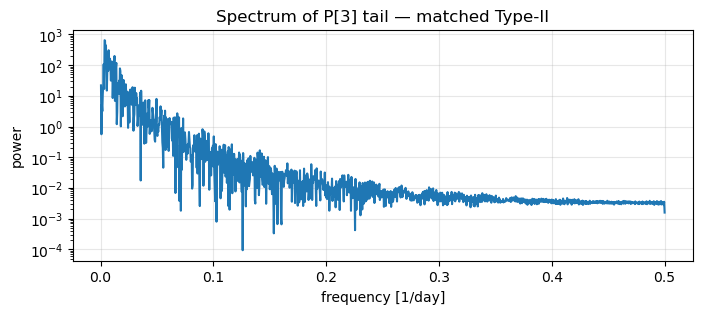

  dominant frequency: 0.0036 /day
  → oscillation period: 277.78 day


In [18]:
# Spectral analysis of one active class's tail.
from scipy.signal import periodogram

ivp_out = runs['NPZ TypeII — matched']['ivp_out']
i_active = ivp_out.Phytoplankton__biomass.mean('time').argmax().item()
t = ivp_out.time.values
P_i = ivp_out.Phytoplankton__biomass.isel(phyto=i_active).values

tail_idx = len(t) // 2
freqs, power = periodogram(P_i[tail_idx:], fs=1.0)  # samples / day

# Power spectrum: peaks at non-zero frequencies → limit cycle
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(freqs[1:], power[1:])  # skip the DC component (mean)
ax.set_xlabel('frequency [1/day]'); ax.set_ylabel('power')
ax.set_title(f'Spectrum of P[{i_active}] tail — matched Type-II')
ax.grid(alpha=0.3)
plt.show()

# Dominant period
peak_idx = 1 + np.argmax(power[1:])
print(f"  dominant frequency: {freqs[peak_idx]:.4f} /day")
print(f"  → oscillation period: {1/freqs[peak_idx]:.2f} day")

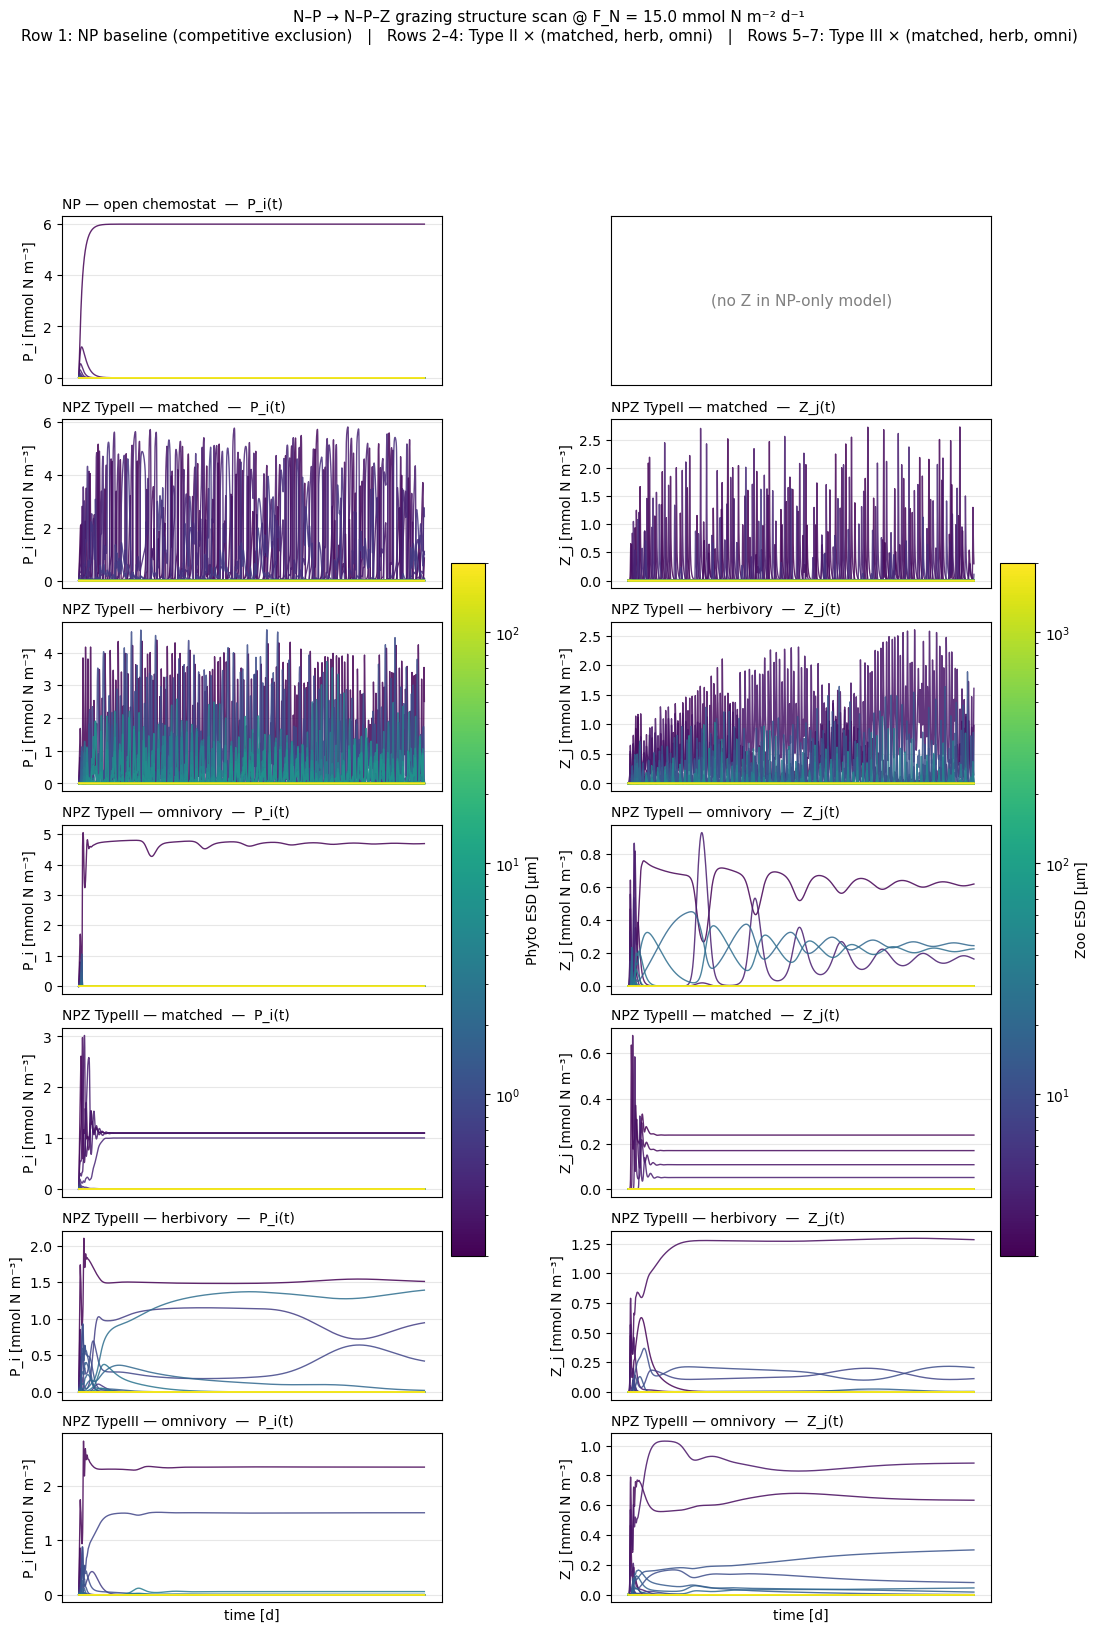

In [13]:
fig, axes = plt.subplots(7, 2, figsize=(13, 18), sharex=True)

cmap   = plt.get_cmap('viridis')
norm_P = mcolors.LogNorm(vmin=phyto_esd.min(), vmax=phyto_esd.max())
norm_Z = mcolors.LogNorm(vmin=zoo_esd.min(),   vmax=zoo_esd.max())

for row, (label, _, _) in enumerate(RUNS_SPEC):
    ivp_out = runs[label]['ivp_out']
    t   = ivp_out.time.values

    # --- P column (always populated)
    ax_P = axes[row, 0]
    P_t  = ivp_out.Phytoplankton__biomass.transpose('time', 'phyto').values
    for i in range(n_classes):
        ax_P.plot(t, P_t[:, i], color=cmap(norm_P(phyto_esd[i])),
                  alpha=0.85, lw=1)
    ax_P.set_title(f'{label}  —  P_i(t)', fontsize=10, loc='left')
    ax_P.set_ylabel('P_i [mmol N m⁻³]')
    ax_P.grid(True, alpha=0.3)

    # --- Z column (NP row is blank)
    ax_Z = axes[row, 1]
    if 'NPZ' in label:
        Z_t = ivp_out.Zooplankton__biomass.transpose('time', 'zoo').values
        for j in range(n_zoo):
            ax_Z.plot(t, Z_t[:, j], color=cmap(norm_Z(zoo_esd[j])),
                      alpha=0.85, lw=1)
        ax_Z.set_title(f'{label}  —  Z_j(t)', fontsize=10, loc='left')
        ax_Z.set_ylabel('Z_j [mmol N m⁻³]')
        ax_Z.grid(True, alpha=0.3)
    else:
        ax_Z.text(0.5, 0.5, '(no Z in NP-only model)',
                  transform=ax_Z.transAxes,
                  ha='center', va='center', color='gray', fontsize=11)
        ax_Z.set_xticks([])
        ax_Z.set_yticks([])

axes[-1, 0].set_xlabel('time [d]')
axes[-1, 1].set_xlabel('time [d]')

sm_P = plt.cm.ScalarMappable(norm=norm_P, cmap=cmap)
sm_Z = plt.cm.ScalarMappable(norm=norm_Z, cmap=cmap)
fig.colorbar(sm_P, ax=axes[:, 0].tolist(), label='Phyto ESD [µm]',
             shrink=0.5, pad=0.02)
fig.colorbar(sm_Z, ax=axes[:, 1].tolist(), label='Zoo ESD [µm]',
             shrink=0.5, pad=0.02)

fig.suptitle(
    f'N–P → N–P–Z grazing structure scan @ F_N = {F_N_ANCHOR} mmol N m⁻² d⁻¹\n'
    f'Row 1: NP baseline (competitive exclusion)   |   '
    f'Rows 2–4: Type II × (matched, herb, omni)   |   '
    f'Rows 5–7: Type III × (matched, herb, omni)',
    fontsize=11, y=0.995)
plt.show()

ValueError: too many values to unpack (expected 2, got 6)

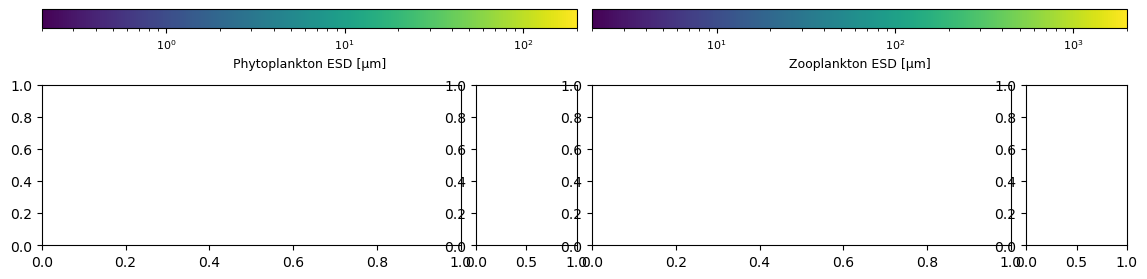

In [14]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 20))
gs = GridSpec(
    nrows=1 + 7, ncols=4,
    width_ratios=[5, 1.2, 5, 1.2],
    height_ratios=[0.35] + [3] * 7,
    hspace=0.40, wspace=0.06,
    figure=fig,
)

cmap   = plt.get_cmap('viridis')
norm_P = mcolors.LogNorm(vmin=phyto_esd.min(), vmax=phyto_esd.max())
norm_Z = mcolors.LogNorm(vmin=zoo_esd.min(),   vmax=zoo_esd.max())
colors_P = [cmap(norm_P(s)) for s in phyto_esd]
colors_Z = [cmap(norm_Z(s)) for s in zoo_esd]

# Top horizontal colorbars
cax_P = fig.add_subplot(gs[0, 0:2])
cax_Z = fig.add_subplot(gs[0, 2:4])
fig.colorbar(plt.cm.ScalarMappable(norm=norm_P, cmap=cmap),
             cax=cax_P, orientation='horizontal').set_label(
    'Phytoplankton ESD [µm]', fontsize=9)
fig.colorbar(plt.cm.ScalarMappable(norm=norm_Z, cmap=cmap),
             cax=cax_Z, orientation='horizontal').set_label(
    'Zooplankton ESD [µm]', fontsize=9)
cax_P.tick_params(labelsize=8)
cax_Z.tick_params(labelsize=8)

# Bar heights for spectrum panels (log-spaced grid)
esd_ratio_P = phyto_esd[1] / phyto_esd[0]
esd_ratio_Z = zoo_esd[1]   / zoo_esd[0]
hfac_P = np.sqrt(esd_ratio_P) - 1.0 / np.sqrt(esd_ratio_P)
hfac_Z = np.sqrt(esd_ratio_Z) - 1.0 / np.sqrt(esd_ratio_Z)
heights_P = phyto_esd * hfac_P
heights_Z = zoo_esd   * hfac_Z

for row_idx, (label, _, _) in enumerate(RUNS_SPEC):
    gs_row  = row_idx + 1
    ax_P_ts = fig.add_subplot(gs[gs_row, 0])
    ax_P_sp = fig.add_subplot(gs[gs_row, 1])
    ax_Z_ts = fig.add_subplot(gs[gs_row, 2])
    ax_Z_sp = fig.add_subplot(gs[gs_row, 3])

    ivp_out, ss_out = runs[label]
    t      = ivp_out.time.values
    is_npz = 'NPZ' in label

    # P time series (IVP transient)
    P_t = ivp_out.Phytoplankton__biomass.transpose('time', 'phyto').values
    for i in range(n_classes):
        ax_P_ts.plot(t, P_t[:, i], color=colors_P[i], alpha=0.85, lw=1)
    ax_P_ts.set_title(label, fontsize=10, loc='left')
    ax_P_ts.set_ylabel('P_i [mmol N m⁻³]')
    ax_P_ts.grid(True, alpha=0.3)

    # P steady-state spectrum (fsolve at time=-1)
    if ss_out is not None:
        P_ss = ss_out.Phytoplankton__biomass.isel(time=-1).values
        ax_P_sp.barh(phyto_esd, P_ss, height=heights_P,
                     color=colors_P, edgecolor='none')
    else:
        ax_P_sp.text(0.5, 0.5, '(no fsolve)', transform=ax_P_sp.transAxes,
                     ha='center', va='center', color='gray', fontsize=8)
    ax_P_sp.set_yscale('log')
    ax_P_sp.set_ylim(phyto_esd[0]  / np.sqrt(esd_ratio_P),
                     phyto_esd[-1] * np.sqrt(esd_ratio_P))
    ax_P_sp.tick_params(axis='y', labelleft=False)
    ax_P_sp.grid(True, alpha=0.3, axis='x')

    # Z column (blank for NP-only)
    if is_npz:
        Z_t = ivp_out.Zooplankton__biomass.transpose('time', 'zoo').values
        for j in range(n_zoo):
            ax_Z_ts.plot(t, Z_t[:, j], color=colors_Z[j], alpha=0.85, lw=1)
        ax_Z_ts.set_title(label, fontsize=10, loc='left')
        ax_Z_ts.set_ylabel('Z_j [mmol N m⁻³]')
        ax_Z_ts.grid(True, alpha=0.3)

        if ss_out is not None:
            Z_ss = ss_out.Zooplankton__biomass.isel(time=-1).values
            ax_Z_sp.barh(zoo_esd, Z_ss, height=heights_Z,
                         color=colors_Z, edgecolor='none')
        else:
            ax_Z_sp.text(0.5, 0.5, '(no fsolve)', transform=ax_Z_sp.transAxes,
                         ha='center', va='center', color='gray', fontsize=8)
        ax_Z_sp.set_yscale('log')
        ax_Z_sp.set_ylim(zoo_esd[0]  / np.sqrt(esd_ratio_Z),
                         zoo_esd[-1] * np.sqrt(esd_ratio_Z))
        ax_Z_sp.tick_params(axis='y', labelleft=False)
        ax_Z_sp.grid(True, alpha=0.3, axis='x')
    else:
        ax_Z_ts.text(0.5, 0.5, '(no Z in NP-only model)',
                     transform=ax_Z_ts.transAxes,
                     ha='center', va='center', color='gray', fontsize=11)
        for ax in (ax_Z_ts, ax_Z_sp):
            ax.set_xticks([]); ax.set_yticks([])

    if row_idx == len(RUNS_SPEC) - 1:
        ax_P_ts.set_xlabel('time [d]')
        ax_P_sp.set_xlabel('P*(s) [mmol N m⁻³]')
        if is_npz:
            ax_Z_ts.set_xlabel('time [d]')
            ax_Z_sp.set_xlabel('Z*(s) [mmol N m⁻³]')

fig.suptitle(
    'NP → NPZ structural grazing scan: per-class IVP time series (wide) '
    '+ fsolve steady-state spectrum (narrow)\n'
    f'F_N = {F_N_ANCHOR} mmol N m⁻² d⁻¹, IVP over 5000 d, '
    'fsolve seeded from last finite IVP state',
    fontsize=11, y=0.99,
)
plt.show()

In [15]:
# Diagnose matched-Type-II: oscillation character + fsolve spectrum structure.

import numpy as np
import matplotlib.pyplot as plt
from np_setups import phyto_esd, zoo_esd

label = 'NPZ TypeII — matched'
ivp_out, ss_out = runs[label]
t = ivp_out.time.values

# Pick the most active P and Z classes (largest time-averaged biomass).
i_P = ivp_out.Phytoplankton__biomass.mean('time').argmax().item()
j_Z = ivp_out.Zooplankton__biomass.mean('time').argmax().item()
P_i = ivp_out.Phytoplankton__biomass.isel(phyto=i_P).values
Z_j = ivp_out.Zooplankton__biomass.isel(zoo=j_Z).values


# === CHECK 1: bounded limit cycle vs growing oscillation =====================
def amp(x):
    return float(np.percentile(x, 95) - np.percentile(x, 5))

n = len(t)
amp_P_q1, amp_P_q4 = amp(P_i[:n//4]), amp(P_i[-n//4:])
amp_Z_q1, amp_Z_q4 = amp(Z_j[:n//4]), amp(Z_j[-n//4:])

print(f"=== Check 1: oscillation amplitude (95-5 pct range), first vs last quarter ===")
print(f"  active P[{i_P}] (ESD={phyto_esd[i_P]:6.2f} µm): "
      f"q1={amp_P_q1:.3g}, q4={amp_P_q4:.3g}, ratio q4/q1={amp_P_q4/max(amp_P_q1,1e-30):.2f}")
print(f"  active Z[{j_Z}] (ESD={zoo_esd[j_Z]:6.2f} µm): "
      f"q1={amp_Z_q1:.3g}, q4={amp_Z_q4:.3g}, ratio q4/q1={amp_Z_q4/max(amp_Z_q1,1e-30):.2f}")
print(f"  ratio >>1 = growing oscillation (concerning); "
      f"~1 = sustained limit cycle (physical); <1 = damping toward equilibrium")

fig, (axP, axZ) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axP.plot(t, P_i, lw=0.6)
axP.set_ylabel(f'P[{i_P}]'); axP.grid(alpha=0.3)
axP.set_title('matched Type-II: active-class time series (linear)')
axZ.plot(t, Z_j, lw=0.6, color='C1')
axZ.set_ylabel(f'Z[{j_Z}]'); axZ.set_xlabel('time [d]'); axZ.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# === CHECK 2: structure of the fsolve steady-state spectrum ==================
P_ss = ss_out.Phytoplankton__biomass.isel(time=-1).values
Z_ss = ss_out.Zooplankton__biomass.isel(time=-1).values

def bin_counts(arr, edges=(1e-3, 1e-6, 1e-9)):
    a = np.abs(arr)
    return [int((a > edges[0]).sum()),
            int(((a > edges[1]) & (a <= edges[0])).sum()),
            int(((a > edges[2]) & (a <= edges[1])).sum()),
            int((a <= edges[2]).sum())]

print(f"\n=== Check 2: fsolve spectrum structure ===")
print(f"  fsolve N         : {float(ss_out.Nutrient__value.isel(time=-1)):.4g}")
print(f"  P |val| bins     : >1e-3:{bin_counts(P_ss)[0]:3d}  "
      f"1e-6..1e-3:{bin_counts(P_ss)[1]:3d}  "
      f"1e-9..1e-6:{bin_counts(P_ss)[2]:3d}  "
      f"≤1e-9:{bin_counts(P_ss)[3]:3d}")
print(f"  Z |val| bins     : >1e-3:{bin_counts(Z_ss)[0]:3d}  "
      f"1e-6..1e-3:{bin_counts(Z_ss)[1]:3d}  "
      f"1e-9..1e-6:{bin_counts(Z_ss)[2]:3d}  "
      f"≤1e-9:{bin_counts(Z_ss)[3]:3d}")
print(f"  P |max|, signed  : |{np.max(np.abs(P_ss)):.3g}|, "
      f"max={np.max(P_ss):+.3g}, min={np.min(P_ss):+.3g}")
print(f"  Z |max|, signed  : |{np.max(np.abs(Z_ss)):.3g}|, "
      f"max={np.max(Z_ss):+.3g}, min={np.min(Z_ss):+.3g}")
print(f"\n  If 'Z |val| bins > 1e-6' has any nonzero entries, masking |Z|<1e-9 "
      f"keeps those\n  and only suppresses the noise floor. If it's all zero, "
      f"fsolve really did\n  put all Z classes at floor for this case.")


# === CHECK 3: IVP tail-mean vs fsolve — agreement on active classes ==========
TAIL = 500
P_tail = ivp_out.Phytoplankton__biomass.isel(time=slice(-TAIL, None)).mean('time').values
Z_tail = ivp_out.Zooplankton__biomass.isel(time=slice(-TAIL, None)).mean('time').values

print(f"\n=== Check 3: IVP tail-mean (last {TAIL}d) vs fsolve, active classes only ===")
print(f"  (For a sustained limit cycle, fsolve should approximate the IVP "
      f"long-time mean.)")
print(f"  Active P classes (|val|>1e-6 in either):")
shown = 0
for i in range(len(P_tail)):
    if abs(P_tail[i]) > 1e-6 or abs(P_ss[i]) > 1e-6:
        print(f"    P[{i:2d}] (ESD={phyto_esd[i]:6.2f}µm): "
              f"tail-mean={P_tail[i]:+.3e}, fsolve={P_ss[i]:+.3e}, "
              f"diff={(P_tail[i]-P_ss[i]):+.2e}")
        shown += 1
if shown == 0:
    print("    (none above 1e-6)")
print(f"  Active Z classes (|val|>1e-6 in either):")
shown = 0
for j in range(len(Z_tail)):
    if abs(Z_tail[j]) > 1e-6 or abs(Z_ss[j]) > 1e-6:
        print(f"    Z[{j:2d}] (ESD={zoo_esd[j]:6.2f}µm): "
              f"tail-mean={Z_tail[j]:+.3e}, fsolve={Z_ss[j]:+.3e}, "
              f"diff={(Z_tail[j]-Z_ss[j]):+.2e}")
        shown += 1
if shown == 0:
    print("    (none above 1e-6 — fsolve found 'everything at floor' steady state)")


# === Plot: fsolve spectrum with and without noise-floor masking ==============
fig, (axP, axZ) = plt.subplots(1, 2, figsize=(13, 4))
P_masked = np.where(np.abs(P_ss) > 1e-9, P_ss, np.nan)
Z_masked = np.where(np.abs(Z_ss) > 1e-9, Z_ss, np.nan)
axP.plot(phyto_esd, P_ss, 'o', color='lightgray', alpha=0.6, label='raw (all 40)')
axP.plot(phyto_esd, P_masked, 'o-', label='|val|>1e-9 only')
axP.set_xscale('log'); axP.set_yscale('symlog', linthresh=1e-12)
axP.set_xlabel('phyto ESD [µm]'); axP.set_ylabel('P_ss')
axP.set_title('fsolve P spectrum'); axP.legend(); axP.grid(alpha=0.3)
axZ.plot(zoo_esd, Z_ss, 'o', color='lightgray', alpha=0.6, label='raw (all 40)')
axZ.plot(zoo_esd, Z_masked, 'o-', color='C1', label='|val|>1e-9 only')
axZ.set_xscale('log'); axZ.set_yscale('symlog', linthresh=1e-12)
axZ.set_xlabel('zoo ESD [µm]'); axZ.set_ylabel('Z_ss')
axZ.set_title('fsolve Z spectrum'); axZ.legend(); axZ.grid(alpha=0.3)
plt.tight_layout(); plt.show()

ValueError: too many values to unpack (expected 2, got 6)

In [8]:
import numpy as np
TAIL = 500
for label in runs:
    if 'NPZ' not in label:
        continue
    ivp_out, ss_out = runs[label]
    P_tail = ivp_out.Phytoplankton__biomass.isel(time=slice(-TAIL,None)).mean('time').values
    Z_tail = ivp_out.Zooplankton__biomass.isel(time=slice(-TAIL,None)).mean('time').values
    P_ss = ss_out.Phytoplankton__biomass.isel(time=-1).values
    Z_ss = ss_out.Zooplankton__biomass.isel(time=-1).values
    n_active_P_tail = int((np.abs(P_tail) > 1e-6).sum())
    n_active_P_ss   = int((np.abs(P_ss)   > 1e-6).sum())
    n_active_Z_tail = int((np.abs(Z_tail) > 1e-6).sum())
    n_active_Z_ss   = int((np.abs(Z_ss)   > 1e-6).sum())
    flag = "  ← FSOLVE DISAGREES" if (n_active_P_tail != n_active_P_ss
                                       or n_active_Z_tail != n_active_Z_ss) else ""
    print(f"{label:<28s}  active P: tail-mean {n_active_P_tail:2d}, "
          f"fsolve {n_active_P_ss:2d}   "
          f"active Z: tail-mean {n_active_Z_tail:2d}, "
          f"fsolve {n_active_Z_ss:2d}{flag}")

NPZ TypeII — matched          active P: tail-mean  8, fsolve  1   active Z: tail-mean  6, fsolve  0  ← FSOLVE DISAGREES
NPZ TypeII — herbivory        active P: tail-mean 10, fsolve  1   active Z: tail-mean 11, fsolve  1  ← FSOLVE DISAGREES
NPZ TypeII — omnivory         active P: tail-mean  1, fsolve  1   active Z: tail-mean  4, fsolve  4
NPZ TypeIII — matched         active P: tail-mean  5, fsolve  5   active Z: tail-mean  4, fsolve  4
NPZ TypeIII — herbivory       active P: tail-mean  6, fsolve  4   active Z: tail-mean  6, fsolve  4  ← FSOLVE DISAGREES
NPZ TypeIII — omnivory        active P: tail-mean  4, fsolve  3   active Z: tail-mean  7, fsolve  5  ← FSOLVE DISAGREES


In [ ]:
def run_np_scan(model_name, ivp_setup_name, stability_setup_name,
                param_name, param_values,
                processes=N_PROCESSES, avg_window=AVG_WINDOW,
                neg_tol=-1e-9, osc_cv_threshold=0.01):
    """Run IVP parscan, then branch on dynamic type per cell:
      - low tail-variability (CV < osc_cv_threshold)  → fixed-point regime,
        run the fsolve-based stability scan as before;
      - high tail-variability                          → limit-cycle regime,
        report the tail-mean directly as the "steady state" representation
        and skip / flag fsolve (its Newton iteration drifts to unstable
        equilibria when seeded near a limit cycle, giving misleading bars
        in the spectrum plot).

    Tail-mean (`seed_ds`) is computed once and returned alongside the
    classification so downstream plotting code can pick the right object
    for each cell.

    Returns
    -------
    ivp_results : xr.Dataset
        IVP time series, unchanged.
    stability_results : xr.Dataset or None
        fsolve + Jacobian output per scan cell. Cells flagged as
        oscillating should be ignored / shown distinctly in plots — the
        fsolve fixed point is not representative for them.
    seed_ds : xr.Dataset
        Per-cell tail-mean over the last `avg_window` time steps. Use
        this for the spectrum bars on oscillating cells.
    oscillating : xr.DataArray
        Bool array indexed by `param_name`. True = limit-cycle cell.
    """
    # 1. IVP scan (unchanged).
    ivp_results = run_xso_parscan(
        model_file_name='np_setups',
        model_name=model_name,
        model_setup_name=ivp_setup_name,
        param_name=param_name,
        param_values=param_values,
        processes=processes,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': avg_window},
    )
    state_vars = ['Nutrient__value', 'Phytoplankton__biomass']
    if not all(v in ivp_results.data_vars for v in state_vars):
        print("  [skip stability] IVP scan returned empty / no state vars")
        return ivp_results, None, None, None

    # 2. Tail-mean and tail-variability per cell.
    tail = ivp_results[state_vars].isel(time=slice(-avg_window, None))
    seed_ds = tail.mean('time')
    tail_std = tail.std('time')

    # Per-cell max coefficient of variation across all entries of all state
    # variables. Use a floor on |mean| so near-zero entries don't blow up
    # the CV — we care about variation relative to the active classes.
    import numpy as np
    cv_floor = 1e-9
    max_cv_per_cell = np.zeros(len(param_values))
    for v in state_vars:
        mean = seed_ds[v].values            # shape (n_param, [n_class])
        std  = tail_std[v].values
        cv = std / np.maximum(np.abs(mean), cv_floor)
        # Reduce over non-param axes (class indices) → max CV per cell.
        non_param_axes = tuple(i for i, d in enumerate(seed_ds[v].dims)
                               if d != param_name)
        if non_param_axes:
            cell_max = np.nanmax(cv, axis=non_param_axes)
        else:
            cell_max = cv
        max_cv_per_cell = np.maximum(max_cv_per_cell, cell_max)

    oscillating = xr.DataArray(
        max_cv_per_cell > osc_cv_threshold,
        dims=(param_name,),
        coords={param_name: param_values},
        name='oscillating',
    )
    n_osc = int(oscillating.sum())
    n_tot = oscillating.size

    print(f"  Dynamic-type classification (CV > {osc_cv_threshold:.1%}):")
    print(f"    fixed-point cells: {n_tot - n_osc:3d}/{n_tot} "
          f"(fsolve fixed point representative)")
    print(f"    limit-cycle cells: {n_osc:3d}/{n_tot} "
          f"(use seed_ds tail-mean for spectrum bars)")
    if n_osc > 0:
        osc_vals = param_values[oscillating.values]
        print(f"    oscillating range : "
              f"{param_name} ∈ [{float(osc_vals.min()):.3g}, "
              f"{float(osc_vals.max()):.3g}]")

    # 3. Negative-value diagnostic (unchanged).
    print(f"  Negative-value check on tail-mean (neg_tol = {neg_tol:.0e}):")
    any_neg = False
    for v in state_vars:
        arr = seed_ds[v].values
        n_neg = int(np.sum(arr < neg_tol))
        n_tot_entries = int(np.size(arr))
        if n_neg > 0:
            any_neg = True
            worst = float(np.nanmin(arr))
            n_below_xso_floor = int(np.sum(arr < -1e-6))
            print(f"    {v}: {n_neg}/{n_tot_entries} entries < {neg_tol:.0e}, "
                  f"worst = {worst:.2e}"
                  + (f", {n_below_xso_floor} past XSO −1e-6 floor"
                     if n_below_xso_floor > 0 else ""))
    if not any_neg:
        print(f"    all tail-mean entries ≥ {neg_tol:.0e}  ✓")

    # 4. Apply strict-positivity floor to seed_ds (in place — used as fsolve
    # seed for all cells; for limit-cycle cells the seed is irrelevant since
    # we ignore the fsolve output, but the parscan API needs a seed for
    # every cell).
    FLOOR = 1e-12
    for v in state_vars:
        seed_ds[v] = seed_ds[v].where(seed_ds[v] > FLOOR, FLOOR)

    # 5. Stability scan via fsolve (unchanged). For limit-cycle cells the
    # results aren't physically meaningful — the `oscillating` flag is the
    # downstream signal to ignore them.
    iv_mapping = {v: v + '_init' for v in state_vars}
    stability_results = run_xso_stabilityscan(
        model_file_name='np_setups',
        model_name=model_name,
        model_setup_name=stability_setup_name,
        param_name=param_name,
        param_values=param_values,
        processes=processes,
        initial_values_ds=seed_ds, iv_mapping=iv_mapping,
    )

    # Re-expose the seed_ds (it's already what was passed to fsolve, but
    # making it a named return value clarifies the contract).
    return ivp_results, stability_results, seed_ds, oscillating

In [9]:
import numpy as np
from np_setups import phyto_esd, zoo_esd

ivp_out, _ = runs['NPZ TypeII — matched']
W = 500  # current window
P = ivp_out.Phytoplankton__biomass
Z = ivp_out.Zooplankton__biomass

for v_name, v in [('P', P), ('Z', Z)]:
    mean_W  = v.isel(time=slice(-W,     None)).mean('time').values
    mean_2W = v.isel(time=slice(-2*W,   None)).mean('time').values
    active  = np.abs(mean_W) > 1e-3   # focus on physically active classes
    if active.any():
        rel_diff = np.abs(mean_2W[active] - mean_W[active]) / np.abs(mean_W[active])
        print(f"  {v_name} tail-mean: window={W}d vs {2*W}d, "
              f"max relative diff on active classes = {rel_diff.max():.2%}")
    else:
        print(f"  {v_name}: no active classes above 1e-3")

  P tail-mean: window=500d vs 1000d, max relative diff on active classes = 51.65%
  Z tail-mean: window=500d vs 1000d, max relative diff on active classes = 75.16%
